# Imports

In [168]:
import torch
from datetime import datetime
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

import sys
sys.path.append('../')
from src.utils.data_preprocessing import DataPreprocessor
from src.utils.model_training import ModelTrainer
from src.models.vgg_1D import VGG_1D

# Variables

In [9]:
SAMPLING_FREQUENCY = 100
TASK = "superdiagnostic"
CLASS_NAMES = ['MI', 'NORM'] # OTHER

DATA_DIR = "../data/raw/ptb_xl_ecg/"

PREPROCESSED_DIR = f"../data/preprocessed/"
SINGLE_BEATS_DIR = PREPROCESSED_DIR + "single_beats/"
IG_DIR = PREPROCESSED_DIR + "integrated_gradients/"

SCALER_DIR = f"../data/results/scaler/"

date_today = datetime.now().strftime("%Y_%m_%d")
MODEL_PATH = f"../src/models/trained/"
HISTORY_PATH = f"../data/results/training_history/"

# ECG-Ableitungsnamen (Standard 12-Lead ECG)
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Load Data

In [3]:
X_train, y_train = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "train")
X_val, y_val = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "val")
X_test, y_test = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "test")

Loading processed data from ../data/preprocessed/ with prefix train
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test


In [4]:
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for split_name, y_split in splits.items():
    y_arr = np.asarray(y_split)
    # Multi-Label: Summiere pro Klasse (Spalte)
    if y_arr.ndim == 2 and y_arr.shape[1] == len(CLASS_NAMES):
        counts = y_arr.sum(axis=0)
    else:
        counts = np.bincount(y_arr, minlength=len(CLASS_NAMES))
    perc = counts / counts.sum() * 100
    print(f"{split_name}:")
    for name, c, p in zip(CLASS_NAMES, counts, perc):
        print(f"  {name}: {int(c)} ({p:.2f}%)")
    print(f"  TOTAL: {int(counts.sum())} (100.00%)\n")

Train:
  MI: 53309 (38.27%)
  NORM: 85984 (61.73%)
  TOTAL: 139293 (100.00%)

Validation:
  MI: 6726 (38.41%)
  NORM: 10786 (61.59%)
  TOTAL: 17512 (100.00%)

Test:
  MI: 6860 (38.75%)
  NORM: 10842 (61.25%)
  TOTAL: 17702 (100.00%)



In [5]:
# [Batch_Size, Channels, Sequence_Length] 
X_test.shape

(17702, 12, 77)

# Load Model

In [6]:
# Initialize for loading existing model
model = VGG_1D(in_channels=12, num_classes=2, input_length=77)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=1e-3)
criterion = ModelTrainer.create_weighted_criterion(y_train, weight_factor=0.7)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=3, min_lr=1e-6)

trainer = ModelTrainer(model, None, None, None, optimizer, criterion, 'cpu', scheduler, None)

In [10]:
epochs = 5
date = "2025_10_27"
spec = 'vgg_variant_B/'

model_name = f"VGG_1D_trained_{date}_epochs{epochs}.pth"
checkpoint_name = f"checkpoint_{date}_epochs{epochs}.pth"
history_name = f"training_history_{date}.csv"

# load existing model
trainer.load_model(MODEL_PATH + spec + model_name)
trainer.load_training_history(CLASS_NAMES, HISTORY_PATH + history_name)

Modell erfolgreich aus '../src/models/trained/vgg_variant_B/VGG_1D_trained_2025_10_27_epochs5.pth' geladen.
Trainingshistorie erfolgreich aus '../data/results/training_history/training_history_2025_10_27.csv' geladen.


In [11]:
print("model.flattened_size:", model.flattened_size)
print("classifier[0].in_features:", model.classifier[0].in_features)
print("classifier[0].weight.shape:", model.classifier[0].weight.shape)

# Die flattened size von 2048 bedeutet, dass nach allen Convolutional- und Pooling-Layern des Modells der
# Output vor dem Eintritt in den Klassifikator (also vor den voll verbundenen Schichten) zu einem Vektor
# der Länge 2048 "flach" gemacht wird.

# Nach den Feature-Extraktionsschritten (Convs, Pooling) bleibt ein Tensor mit der Form [Batch, 2048] übrig.
# Dieser Vektor ist die "flattened" Repräsentation aller extrahierten Merkmale und dient als Input für die
# erste Fully-Connected-Schicht (classifier[0]).

# 256 Zeilen (Neuronen) × 2048 Spalten (Input-Features)

model.flattened_size: 1024
classifier[0].in_features: 1024
classifier[0].weight.shape: torch.Size([256, 1024])


# Integrated Gradients

## Utils

In [12]:
model.eval()

VGG_1D(
  (features): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv1d(128, 256, kernel_size=(3,), 

In [13]:
def grab_samples(y_test, target_label_name, sample_size=5):
    # Target-Index finden
    target_idx = CLASS_NAMES.index(target_label_name)
    
    # Alle Samples mit dem gewünschten Label finden
    y_test_array = np.array(y_test)
    if y_test_array.ndim == 2:  # Multi-label format
        sample_indices = np.where(y_test_array[:, target_idx] == 1)[0]
    else:  # Single-label format
        sample_indices = np.where(y_test_array == target_idx)[0]
    
    sample_size_max = len(sample_indices)
    sample_size = sample_size_max if sample_size > sample_size_max else sample_size
    
    # maximal bis sample_size, für schnellere Berechnung, zufällig auswählen
    if sample_size_max > sample_size:
        sample_indices = np.random.choice(sample_indices, size=sample_size, replace=False)
    # else: take all samples

    print(f"Zufällig verarbeitete {target_label_name}-Samples: {len(sample_indices)} von {sample_size_max} (max)")
    return sample_indices, target_idx

In [170]:
def compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx):
    ig = IntegratedGradients(model)

    # Attributionen für alle gefundenen Samples berechnen
    all_attributions = []
    convergence_deltas = []

    for i, sample_idx in enumerate(tqdm(sample_indices, desc=f"Computing attributions for target {target_idx}")):
        # Input-Daten vorbereiten
        sample_data = torch.tensor(X_test[sample_idx:sample_idx+1]).float()
        
        # Baseline (Nullvektor)
        baseline = torch.zeros_like(sample_data)
        
        # Attribution berechnen (für die Target-Klasse)
        attribution, convergence_delta = ig.attribute(
            sample_data, target=target_idx, baselines=baseline, 
            method='gausslegendre', return_convergence_delta=True,
            n_steps=100)
        
        # Speichern
        all_attributions.append(attribution.numpy())
        convergence_deltas.append(convergence_delta.item())
        
    return all_attributions, convergence_deltas

In [171]:
sample_size_to_observe = 11000

In [172]:
import matplotlib.colors as mcolors
# Eigene Colormap erstellen: Dunkelgrün -> Weiß -> Dunkelrot
colors = ['darkgreen', 'white', 'darkred']
n_bins = 256  # Anzahl der Farbstufen
cmap_green_white_red = mcolors.LinearSegmentedColormap.from_list('green_white_red', colors, N=n_bins)
cmap_red_white_green = mcolors.LinearSegmentedColormap.from_list('red_white_green', colors[::-1], N=n_bins)

light_green = "#b4d1b4"
light_red = "#d19b9b"

cmap_custom_greens = mcolors.LinearSegmentedColormap.from_list('custom_greens', ["#e3ffe3", 'darkgreen'], N=n_bins)
cmap_custom_reds = mcolors.LinearSegmentedColormap.from_list('custom_reds', ["#f9d8d8", 'darkred'], N=n_bins)

## Label: NORM

In [173]:
sample_indices_NORM, target_idx_NORM = grab_samples(y_test, "NORM", sample_size_to_observe)
attributions_NORM, convergence_deltas_NORM = compute_integrated_gradients_for_label(model, X_test, sample_indices_NORM, target_idx_NORM)

Zufällig verarbeitete NORM-Samples: 10842 von 10842 (max)


Computing attributions for target 1: 100%|██████████| 10842/10842 [24:00<00:00,  7.53it/s] 


In [174]:
def save_attributions(attributions, indices, deltas, filename_prefix):
    with open(IG_DIR + f"{filename_prefix}_attributions.pkl", "wb") as f:
        pickle.dump(attributions, f)
    with open(IG_DIR + f"{filename_prefix}_indices.pkl", "wb") as f:
        pickle.dump(indices, f)
    with open(IG_DIR + f"{filename_prefix}_deltas.pkl", "wb") as f:
        pickle.dump(deltas, f)

save_attributions(attributions_NORM, sample_indices_NORM, convergence_deltas_NORM, "NORM")

In [175]:
def load_attributions(filename_prefix):
    with open(IG_DIR + f"{filename_prefix}_attributions.pkl", "rb") as f:
        attributions = pickle.load(f)
    with open(IG_DIR + f"{filename_prefix}_indices.pkl", "rb") as f:
        indices = pickle.load(f)
    with open(IG_DIR + f"{filename_prefix}_deltas.pkl", "rb") as f:
        deltas = pickle.load(f)
    return attributions, indices, deltas

attributions_NORM, sample_indices_NORM, convergence_deltas_NORM = load_attributions("NORM")

Convergence Delta: [-0.03583550453186035, -0.005631923675537109, -0.036667823791503906, -0.03453671932220459, 0.020961523056030273, -0.08240675926208496, 0.04325103759765625, 0.007891178131103516, -0.035036325454711914, -0.007975399494171143, 0.01460111141204834, 0.028528451919555664, 0.0023249387741088867, -0.03960251808166504, -0.022763192653656006, -0.025997519493103027, 0.031039714813232422, 0.03260672092437744, -0.012760281562805176, -0.023951411247253418, 0.019086718559265137, 0.012257695198059082, -0.0179750919342041, -0.12611186504364014, 0.03365480899810791, 0.06017613410949707, -0.0009808540344238281, -0.06082117557525635, -0.015590429306030273, 0.008476495742797852, -0.0039517879486083984, 0.011036276817321777, -0.0173647403717041, -0.04252195358276367, -0.011799097061157227, -0.02931833267211914, -0.01645374298095703, 0.0025086402893066406, 0.04981565475463867, -0.02542710304260254, 0.017712116241455078, -0.01873636245727539, 0.03350663185119629, -0.03353738784790039, 0.026

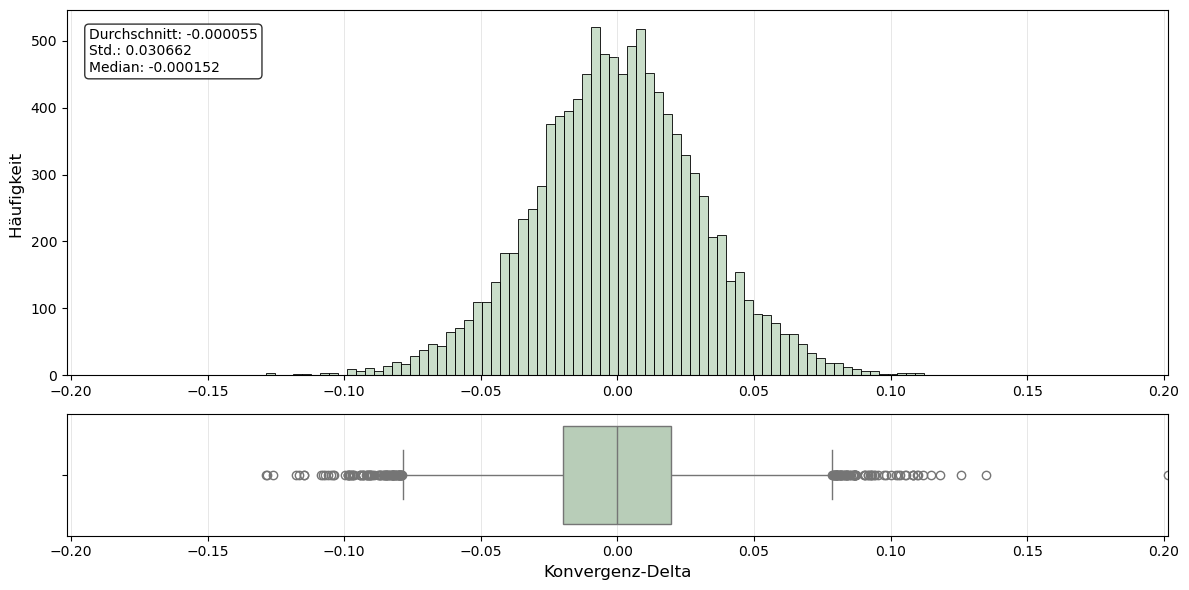

In [176]:
# convergence_delta ist ein Wert, der misst, wie gut die Integrated Gradients die Completeness-Eigenschaft erfüllen:
# Die Summe der Attributionen sollte möglichst genau der Differenz zwischen Modell-Output für das echte Sample und
# die Baseline entsprechen (f(x) - f(baseline)).

# Typische Anwendungen:
# Qualitätskontrolle: Ein kleiner Wert zeigt, dass die Attributionen zuverlässig sind. Ein großer Wert kann auf Probleme
#   (z.B. Modellinstabilität, ungeeignete Baseline) hinweisen.
# Debugging: Du kannst convergence_delta für jedes Sample ausgeben, plotten oder als Filter verwenden (z.B. nur Attributionen
#   mit kleinem delta weiter analysieren).

# Kleine Werte (nahe 0): Die Attributionen sind zuverlässig und erfüllen die Completeness-Eigenschaft gut
# Große Werte: Die Attributionen sind weniger zuverlässig. Mögliche Ursachen: Modellinstabilität, ungeeignete Baseline, numerische Probleme

print("Convergence Delta:", convergence_deltas_NORM)

def plot_convergence_delta_hist_and_box(convergence_deltas, label, color_label):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    ax_hist = axes[0]
    sns.histplot(convergence_deltas, bins=100, alpha=0.7, ax=ax_hist, color=color_label)

    max_abs_value = max(abs(np.min(convergence_deltas)), abs(np.max(convergence_deltas)))
    ax_hist.set_xlim(-max_abs_value, max_abs_value)

    #title_hist = f"Histogramm der Konvergenz-Deltas ({len(convergence_deltas)} Signale - {label})"
    #title_box = f"Boxplot of Convergence Deltas ({len(convergence_deltas)} Samples - {label})"
    #ax_hist.set_title(title_hist, fontsize=16, pad=10)
    ax_hist.set_ylabel('Häufigkeit ', fontsize=12)
    ax_hist.tick_params(axis='x', labelbottom=True)

    stats_text = f'Durchschnitt: {np.mean(convergence_deltas):.6f}\nStd.: {np.std(convergence_deltas):.6f}\nMedian: {np.median(convergence_deltas):.6f}'
    ax_hist.text(0.02, 0.95, stats_text, transform=ax_hist.transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_hist.grid(True, axis='x', alpha=0.3, linewidth=0.7)

    # Boxplot
    ax_box = axes[1]
    sns.boxplot(x=convergence_deltas, color=color_label, ax=ax_box)
    #ax_box.set_title(title_box, fontsize=16, pad=10)
    ax_box.set_xlabel('Konvergenz-Delta', fontsize=12)
    ax_box.grid(True, axis='x', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    plt.show()

plot_convergence_delta_hist_and_box(convergence_deltas_NORM, "NORM", light_green)

In [177]:
def attribution_statistics(attributions):
    # Attribution-Verteilungsanalyse
    attr_flat = np.concatenate([attr.flatten() for attr in attributions])

    print("=== ATTRIBUTION ANALYSIS ===")
    print(f"Samples: {len(attributions)}")
    print(f"Total attribution values per sample: {len(attr_flat)} (Samples*Leads*Sequence Length)")
    print(f"Min: {np.min(attr_flat):.6f} (less influence)")
    print(f"Max: {np.max(attr_flat):.6f} (most influence)")
    print(f"Mean: {np.mean(attr_flat):.6f}")
    print(f"Std: {np.std(attr_flat):.6f}")
    print()

    # Percentage Distribution
    threshold_low = 0.1
    threshold_high = -0.1
    neutral = np.sum((attr_flat >= threshold_high) & (attr_flat <= threshold_low))
    positive = np.sum(attr_flat > threshold_low)
    negative = np.sum(attr_flat < threshold_high)

    print("Proportion of values that have almost no, positive, or negative \ninfluence on the decision for the target class.")
    print(f"Neutral (-0.1 < x < 0.1): {neutral} ({neutral/len(attr_flat)*100:.1f}%)")
    print(f"Positive (x > 0.1): {positive} ({positive/len(attr_flat)*100:.1f}%)")
    print(f"Negative (x < -0.1): {negative} ({negative/len(attr_flat)*100:.1f}%)")

    return attr_flat

attr_flat_NORM = attribution_statistics(attributions_NORM)

=== ATTRIBUTION ANALYSIS ===
Samples: 10842
Total attribution values per sample: 10018008 (Samples*Leads*Sequence Length)
Min: -2.789213 (less influence)
Max: 3.671636 (most influence)
Mean: 0.001570
Std: 0.059394

Proportion of values that have almost no, positive, or negative 
influence on the decision for the target class.
Neutral (-0.1 < x < 0.1): 9680043 (96.6%)
Positive (x > 0.1): 180106 (1.8%)
Negative (x < -0.1): 157859 (1.6%)


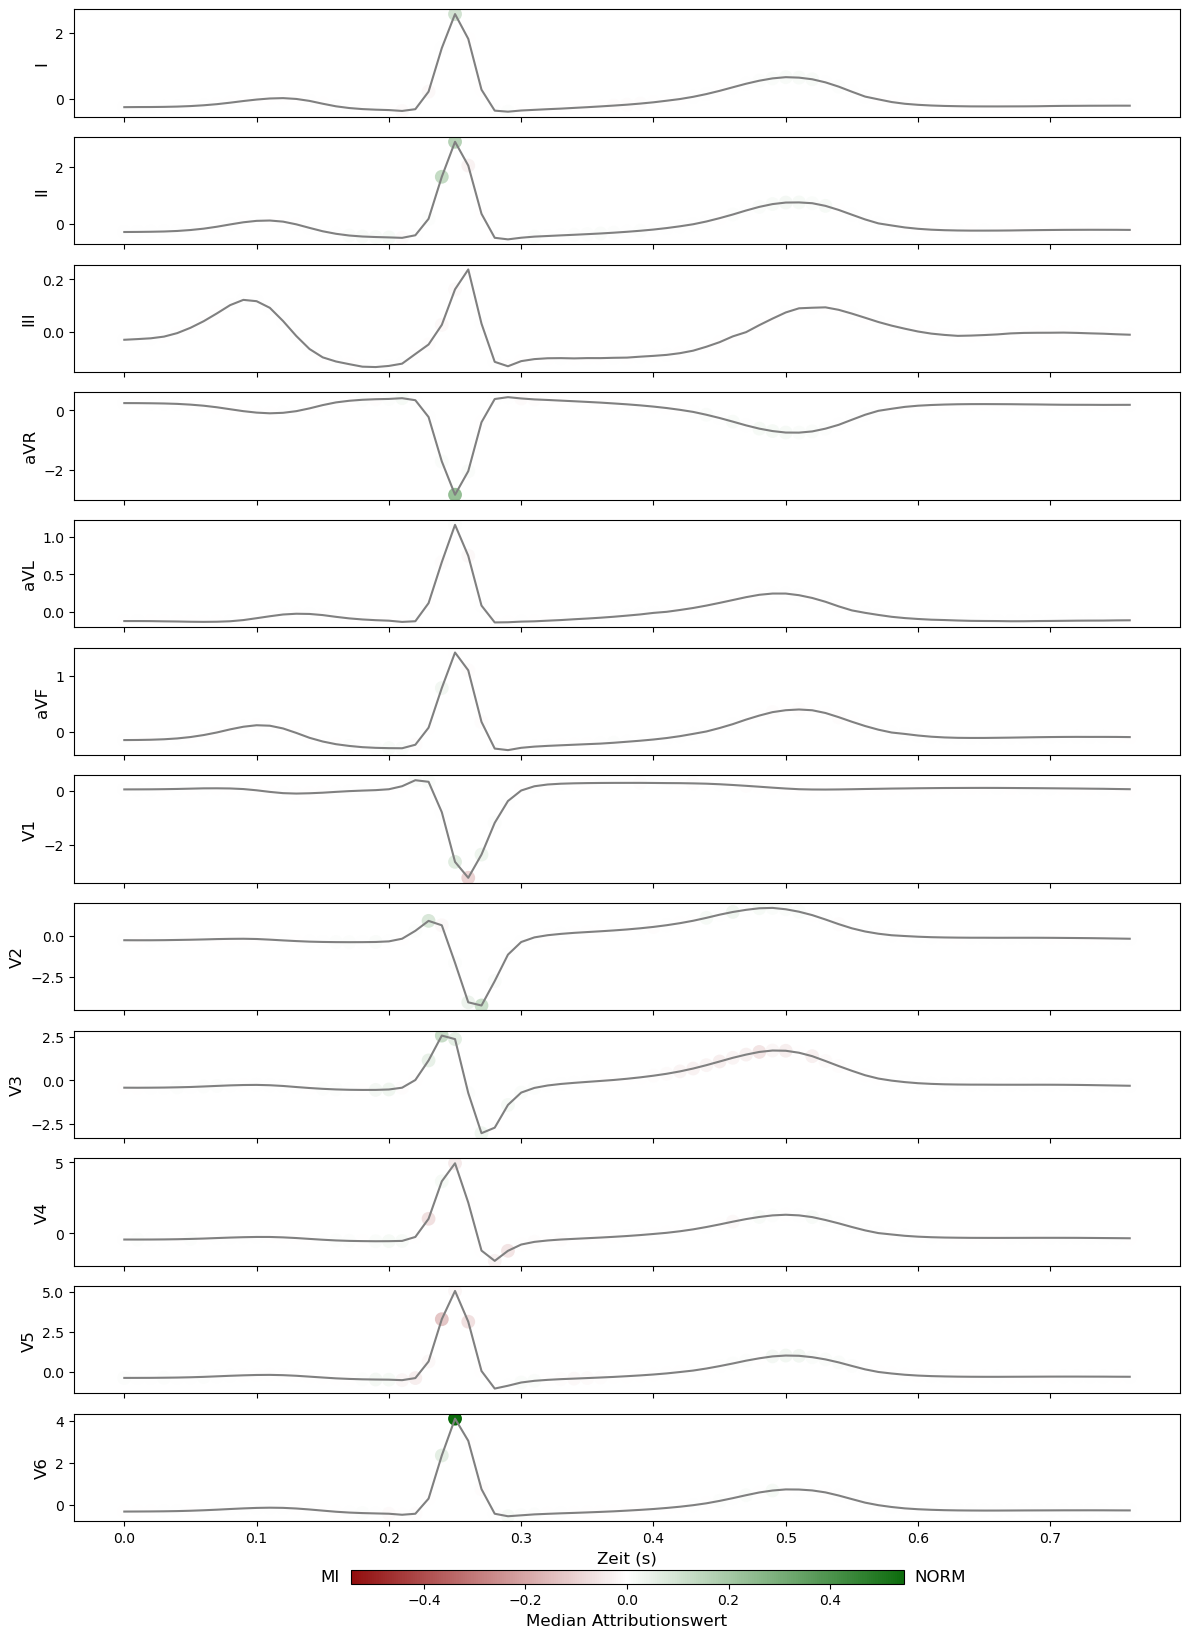

In [178]:
def mean_attribution_per_lead_time(attributions, lead_names):
    "Wie wichtig war dieser Zeitpunkt in dieser Ableitung im Durchschnitt für die Modellentscheidung (für die Klasse NORM)?"
    # Attributionen zu [samples, time, leads] bringen
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]
    mean_attr = np.mean(attr_arr, axis=0)  # [time, leads]
    return mean_attr

def median_attribution_per_lead_time(attributions, lead_names):
    """
    Berechnet den Median der Attributionen je Zeitpunkt und je Ableitung über alle Samples.
    Ergebnis: [time, leads]
    """
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]
    median_attr = np.median(attr_arr, axis=0)  # [time, leads]
    return median_attr

def mean_median_signal_per_lead_time(X, sample_indices, lead_names, method='Mittelwert'):
    # Hole die entsprechenden EKG-Signale
    signals = []
    for idx in sample_indices:
        signal = X[idx]
        if signal.shape[0] == len(lead_names):
            signal = signal.T  # [time, leads]
        signals.append(signal)
    signals = np.array(signals)  # [samples, time, leads]
    if method == 'Mittelwert':
        mean_signal = np.mean(signals, axis=0)  # [time, leads]
    elif method == 'median':
        mean_signal = np.median(signals, axis=0)  # [time, leads]
    return mean_signal

def plot_ecg_attributions_summary(attributions, X, sample_indices, lead_names, sampling_frequency=100, method='mean', class_name="X", color_label=None, figsize=(12, 17)):
    """
    Plottet die mittleren oder medianen Attributionen pro Zeitpunkt und Lead.
    method: 'mean' oder 'median'
    """
    # Signalmittelwert
    if method == 'mean':
        mean_signal = mean_median_signal_per_lead_time(X, sample_indices, lead_names, method='mean')
        attr = mean_attribution_per_lead_time(attributions, lead_names)
        label = 'Mittlerer Attributionswert'
        title_prefix = f"Mittleres"
    elif method == 'median':
        mean_signal = mean_median_signal_per_lead_time(X, sample_indices, lead_names, method='median')
        attr = median_attribution_per_lead_time(attributions, lead_names)
        label = 'Median Attributionswert'
        title_prefix = f"Medianes"
    else:
        raise ValueError("method must be 'mean' or 'median'")
    
    # Symmetrische Farbskala um 0
    vmin = -max(abs(attr.min()), abs(attr.max()))
    vmax = max(abs(attr.min()), abs(attr.max()))
    
    # Plot
    fig, axes = plt.subplots(len(lead_names), 1, figsize=figsize, sharex=True)
    #fig.suptitle(f"{title_prefix} EKG-Signal mit {label} pro Ableitung ({len(sample_indices)} Samples - {class_name})", fontsize=14, y=0.995)
    time_axis = np.arange(mean_signal.shape[0]) / sampling_frequency

    scatters = []
    for i in range(len(lead_names)):
        axes[i].plot(time_axis, mean_signal[:, i], color='grey', label='Mittleres EKG')
        scatter = axes[i].scatter(
            time_axis, mean_signal[:, i], c=attr[:, i],
            cmap=color_label, s=80, alpha=0.95, vmin=vmin, vmax=vmax
        )
        scatters.append(scatter)
        axes[i].set_ylabel(lead_names[i], fontsize=12)

    axes[-1].set_xlabel('Zeit (s)', fontsize=12)
    plt.tight_layout()
    cbar = fig.colorbar(scatters[0], ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, aspect=40, shrink=0.5)
    cbar.set_label(f'{label}', fontsize=12)
    cbar.ax.xaxis.set_label_position('bottom')

    # Zusätzliche Labels links und rechts der Colorbar
    if class_name=="NORM":
        left = 'MI'
        right = 'NORM'
    else:
        left = 'NORM'
        right = 'MI'
            
    cbar_ax = cbar.ax
    cbar_ax.text(-0.02, 0.5, left, ha='right', va='center', transform=cbar_ax.transAxes, fontsize=12)
    cbar_ax.text(1.02, 0.5, right, ha='left', va='center', transform=cbar_ax.transAxes, fontsize=12)

    plt.show()

plot_ecg_attributions_summary(
    attributions_NORM, X_test, sample_indices_NORM, lead_names,
    SAMPLING_FREQUENCY, 'median', "NORM", cmap_red_white_green)

In [202]:
def create_attribution_ranking_dataframe(attributions, lead_names, sampling_frequency=100, top_n=100, method='median'):
    """
    Erstellt ein DataFrame mit den wichtigsten Attributionspunkten, sortiert nach Attributionswert.
    
    Args:
        attributions: Liste von Attributionen
        lead_names: Liste der Lead-Namen
        sampling_frequency: Sampling-Frequenz für Zeitberechnung
        top_n: Anzahl der Top-Attributionspunkte (None für alle)
        method: 'median' oder 'mean' für Aggregation über Samples
    
    Returns:
        pandas.DataFrame mit Spalten: Ableitung, Zeit_s, Zeit_Sample, Attributionswert
    """
    
    # Attributionen berechnen basierend auf der gewählten Methode
    if method == 'median':
        attr = median_attribution_per_lead_time(attributions, lead_names)
    elif method == 'mean':
        attr = mean_attribution_per_lead_time(attributions, lead_names)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    
    # Listen für DataFrame erstellen
    ableitungen = []
    zeiten_s = []
    zeiten_samples = []
    attributionswerte = []
    
    # Durch alle Zeitpunkte und Ableitungen iterieren
    for time_idx in range(attr.shape[0]):  # Zeit-Dimension
        for lead_idx in range(attr.shape[1]):  # Lead-Dimension
            ableitungen.append(lead_names[lead_idx])
            zeiten_s.append(time_idx / sampling_frequency)
            zeiten_samples.append(time_idx)
            attributionswerte.append(attr[time_idx, lead_idx])
    
    # DataFrame erstellen
    df = pd.DataFrame({
        'Ableitung': ableitungen,
        'Zeit_s': zeiten_s,
        'Zeit_Sample': zeiten_samples,
        'Attributionswert': attributionswerte
    })
    
    # Nach absolutem Attributionswert sortieren (höchste Werte zuerst)
    df = df.reindex(df['Attributionswert'].abs().sort_values(ascending=False).index)
    
    # Optional: Nur Top-N Werte zurückgeben
    if top_n is not None:
        df = df.head(top_n)
    
    # Index zurücksetzen
    df = df.reset_index(drop=True)
    
    return df

def create_separated_attribution_ranking(attributions, lead_names, sampling_frequency=100, top_n=25, method='median'):
    """
    Erstellt getrennte Rankings für positive und negative Attributionen.
    """
    df_full = create_attribution_ranking_dataframe(attributions, lead_names, sampling_frequency, top_n=None, method=method)
    
    # Positive und negative Attributionen trennen
    df_positive = df_full[df_full['Attributionswert'] > 0].head(top_n)
    df_negative = df_full[df_full['Attributionswert'] < 0].head(top_n)
    
    return df_positive, df_negative

# Ranking für NORM-Klasse erstellen (Top 50 Attributionspunkte)
ranking_NORM = create_attribution_ranking_dataframe(
    attributions_NORM, 
    lead_names, 
    SAMPLING_FREQUENCY, 
    top_n=50, 
    method='median'
)

# Getrennte Rankings für NORM
pos_NORM, neg_NORM = create_separated_attribution_ranking(attributions_NORM, lead_names, SAMPLING_FREQUENCY, top_n=25)

print("\n\nTop 25 POSITIVE Attributionspunkte für NORM-Klasse:")
print("=" * 70)
print(pos_NORM.to_string(index=True, float_format='%.6f'))

print("\n\nTop 25 NEGATIVE Attributionspunkte für NORM-Klasse:")
print("=" * 70)
print(neg_NORM.to_string(index=True, float_format='%.6f'))



Top 25 POSITIVE Attributionspunkte für NORM-Klasse:
   Ableitung   Zeit_s  Zeit_Sample  Attributionswert
0         V6 0.250000           25          0.544522
1        aVR 0.250000           25          0.231453
2         II 0.250000           25          0.159944
3         II 0.240000           24          0.128438
5         V3 0.240000           24          0.122229
6         V2 0.270000           27          0.113522
7          I 0.250000           25          0.099728
9         V2 0.230000           23          0.083309
10        V1 0.250000           25          0.067432
14        V3 0.250000           25          0.055726
15        V6 0.240000           24          0.055678
17        V3 0.230000           23          0.048574
19        V2 0.260000           26          0.040912
21        V1 0.270000           27          0.036151
24        V2 0.460000           46          0.033986
25        V3 0.200000           20          0.033513
27        V3 0.270000           27          0

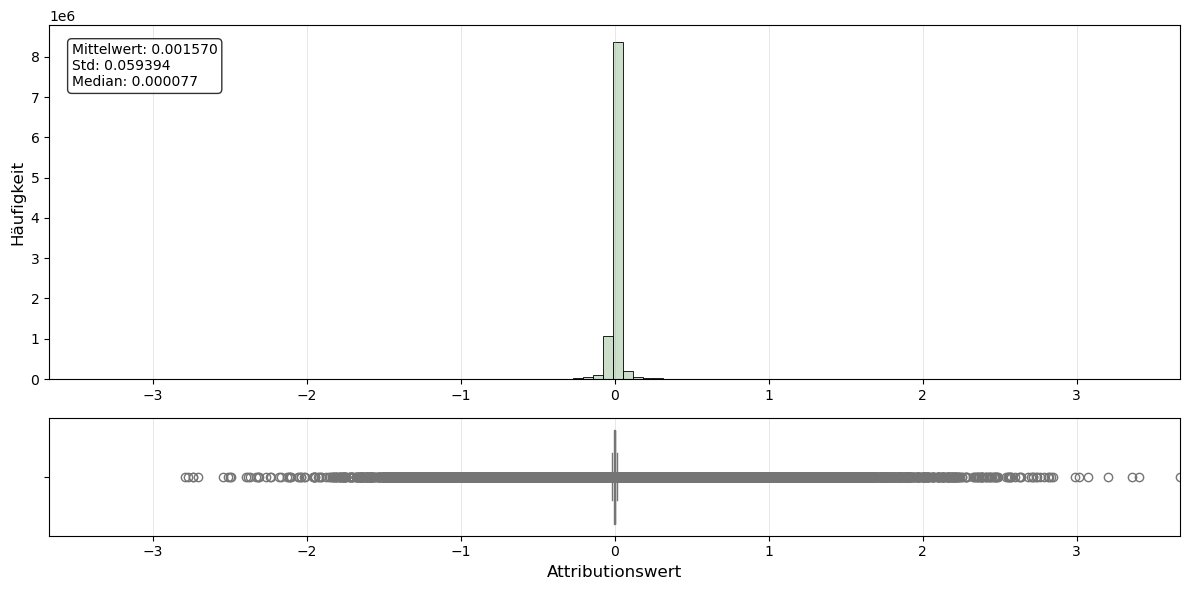

In [179]:
def plot_attribution_hist_and_box(flatten_attributions, label, color_label):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    ax_hist = axes[0]
    sns.histplot(flatten_attributions, bins=100, alpha=0.7, ax=ax_hist, color=color_label)

    max_abs_value = max(abs(np.min(flatten_attributions)), abs(np.max(flatten_attributions)))
    ax_hist.set_xlim(-max_abs_value, max_abs_value)

    # title_hist = f"Histogramm der Attributionswerte ({sample_size_to_observe} Signale - {label})"
    # title_box = f"Verteilung der Attributionswerte ({sample_size_to_observe} Signale - {label})"
    #ax_hist.set_title(title_hist, fontsize=16, pad=10)
    ax_hist.set_ylabel('Häufigkeit', fontsize=12)
    ax_hist.tick_params(axis='x', labelbottom=True)

    stats_text = f'Mittelwert: {np.mean(flatten_attributions):.6f}\nStd: {np.std(flatten_attributions):.6f}\nMedian: {np.median(flatten_attributions):.6f}'
    ax_hist.text(0.02, 0.95, stats_text, transform=ax_hist.transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_hist.grid(True, axis='x', alpha=0.3, linewidth=0.7)

    # Boxplot
    ax_box = axes[1]
    sns.boxplot(x=flatten_attributions, color=color_label, ax=ax_box)
    #ax_box.set_title(title_box, fontsize=16, pad=10)
    ax_box.set_xlabel('Attributionswert', fontsize=12)
    ax_box.grid(True, axis='x', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    plt.show()

# Positiver Wert: Der Input hat einen positiven Einfluss auf die Entscheidung für die Zielklasse (z.B. spricht für MI)
# Negativer Wert: Der Input hat einen negativen Einfluss (spricht gegen die Zielklasse)
# Wert nahe 0: Der Input hat kaum Einfluss auf die Entscheidung.
plot_attribution_hist_and_box(attr_flat_NORM, "NORM", light_green)

In [180]:
# filter = 3
# # filter attributionen
# filtered_attributions_NORM = [attributions_NORM[i] for i in range(len(attributions_NORM)) if -filter <= convergence_deltas_NORM[i] <= filter]
# # Flache Liste für Histogramm/Boxplot erzeugen
# filtered_attr_flat_NORM = np.concatenate([attr.flatten() for attr in filtered_attributions_NORM])

# # Wie viel Prozent fallen in filtered_attributions_NORM rein?
# print(f"Percentage of attributions with convergence delta between -{filter} and {filter}: {len(filtered_attributions_NORM) / len(attributions_NORM) * 100:.2f}%")

# plot_attribution_hist_and_box(filtered_attr_flat_NORM, "NORM", light_green)

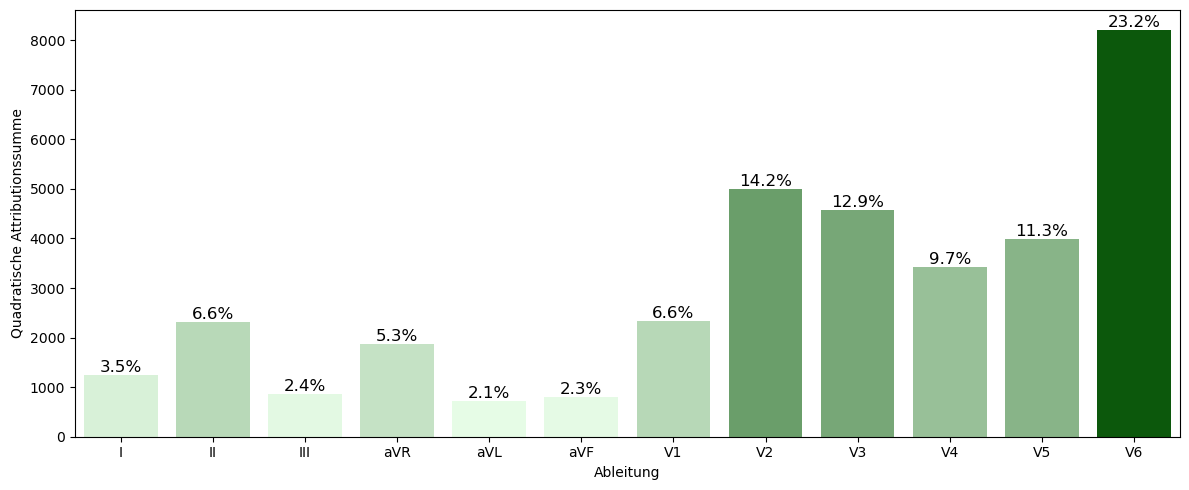

In [188]:
def plot_leadwise_attribution_sum(attributions, lead_names, class_name="X", color_labels=None):
    """
    Plottet die Summe der Attributionen pro Ableitung (Lead) als Balkendiagramm.
    Args:
        attributions: Liste von Attributionen, z.B. [samples][1, leads, time] oder [samples][1, time, leads]
        lead_names: Liste der Lead-Namen
    """
    # Attributionen zu [samples, time, leads] bringen
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]

    # Summe pro Lead über alle Samples und Zeitpunkte
    lead_sums = np.sum(attr_arr, axis=(0, 1))  # [leads]
    lead_squared_sums = np.sum(attr_arr ** 2, axis=(0, 1))  # [leads]

    # Prozentuale Verteilung (bezogen auf die Summe aller Leads)
    percent = 100 * lead_squared_sums / np.sum(lead_squared_sums)

    # DataFrame für hue-Farbe
    import pandas as pd
    df = pd.DataFrame({'Lead': lead_names, 'Value': lead_squared_sums})

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(data=df, x='Lead', y='Value', hue='Value', palette=color_labels, dodge=False, legend=False)
    #plt.title(f"Quadratische Attributionssumme pro Ableitung ({len(attributions)} Signale - {class_name})")
    plt.ylabel("Quadratische Attributionssumme")
    plt.xlabel("Ableitung")
    plt.tight_layout()

    # Prozentwerte über die Balken schreiben
    for i, p in enumerate(percent):
        ax.text(i, lead_squared_sums[i], f"{p:.1f}%", ha='center', va='bottom', fontsize=12)

    plt.show()

plot_leadwise_attribution_sum(attributions_NORM, lead_names, "NORM", cmap_custom_greens)
#plot_leadwise_attribution_sum(filtered_attributions_NORM, lead_names, "NORM - filtered", cmap_custom_greens)

## Label: MI

In [182]:
sample_indices_MI, target_idx_MI = grab_samples(y_test, "MI", sample_size_to_observe)
attributions_MI, convergence_deltas_MI = compute_integrated_gradients_for_label(model, X_test, sample_indices_MI, target_idx_MI)

Zufällig verarbeitete MI-Samples: 6860 von 6860 (max)


Computing attributions for target 0: 100%|██████████| 6860/6860 [16:02<00:00,  7.13it/s]


In [183]:
save_attributions(attributions_MI, sample_indices_MI, convergence_deltas_MI, "MI")

In [184]:
attributions_MI, sample_indices_MI, convergence_deltas_MI = load_attributions("MI")

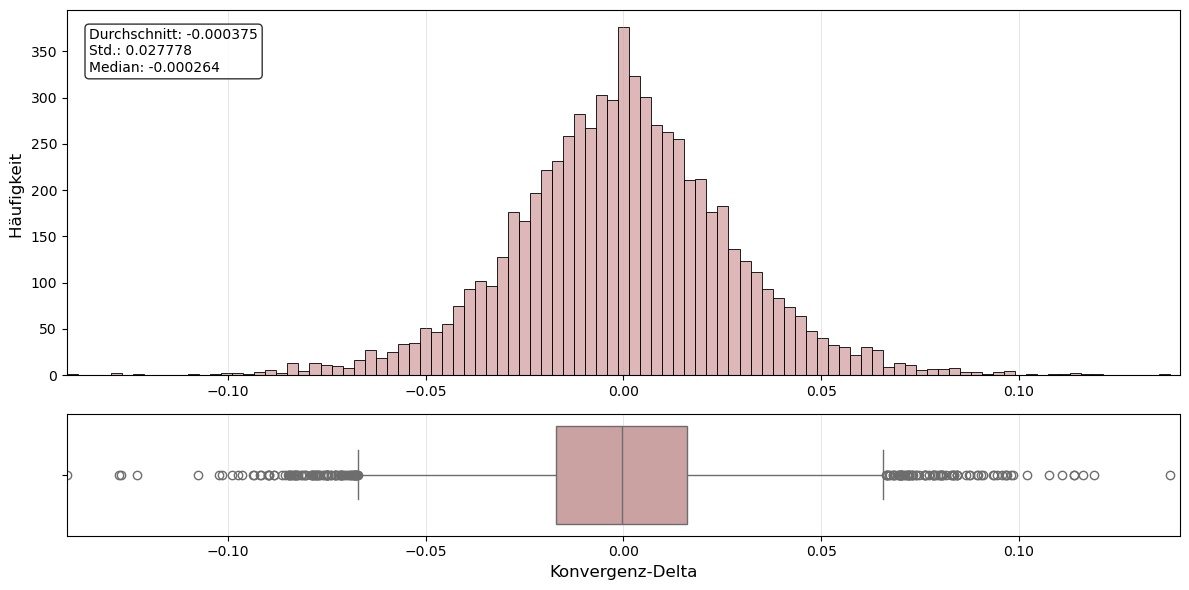

In [189]:
# convergence_delta ist ein Wert, der misst, wie gut die Integrated Gradients die Completeness-Eigenschaft erfüllen:
# Die Summe der Attributionen sollte möglichst genau der Differenz zwischen Modell-Output für das echte Sample und
# die Baseline entsprechen (f(x) - f(baseline)).

# Typische Anwendungen:
# Qualitätskontrolle: Ein kleiner Wert zeigt, dass die Attributionen zuverlässig sind. Ein großer Wert kann auf Probleme
#   (z.B. Modellinstabilität, ungeeignete Baseline) hinweisen.
# Debugging: Du kannst convergence_delta für jedes Sample ausgeben, plotten oder als Filter verwenden (z.B. nur Attributionen
#   mit kleinem delta weiter analysieren).

# Kleine Werte (nahe 0): Die Attributionen sind zuverlässig und erfüllen die Completeness-Eigenschaft gut.
# Große Werte: Die Attributionen sind weniger zuverlässig. Mögliche Ursachen: Modellinstabilität, ungeeignete Baseline, numerische Probleme.

plot_convergence_delta_hist_and_box(convergence_deltas_MI, "MI", light_red)

In [190]:
attr_flat_MI = attribution_statistics(attributions_MI)

=== ATTRIBUTION ANALYSIS ===
Samples: 6860
Total attribution values per sample: 6338640 (Samples*Leads*Sequence Length)
Min: -3.528626 (less influence)
Max: 2.775839 (most influence)
Mean: 0.001723
Std: 0.054586

Proportion of values that have almost no, positive, or negative 
influence on the decision for the target class.
Neutral (-0.1 < x < 0.1): 6149265 (97.0%)
Positive (x > 0.1): 110335 (1.7%)
Negative (x < -0.1): 79040 (1.2%)


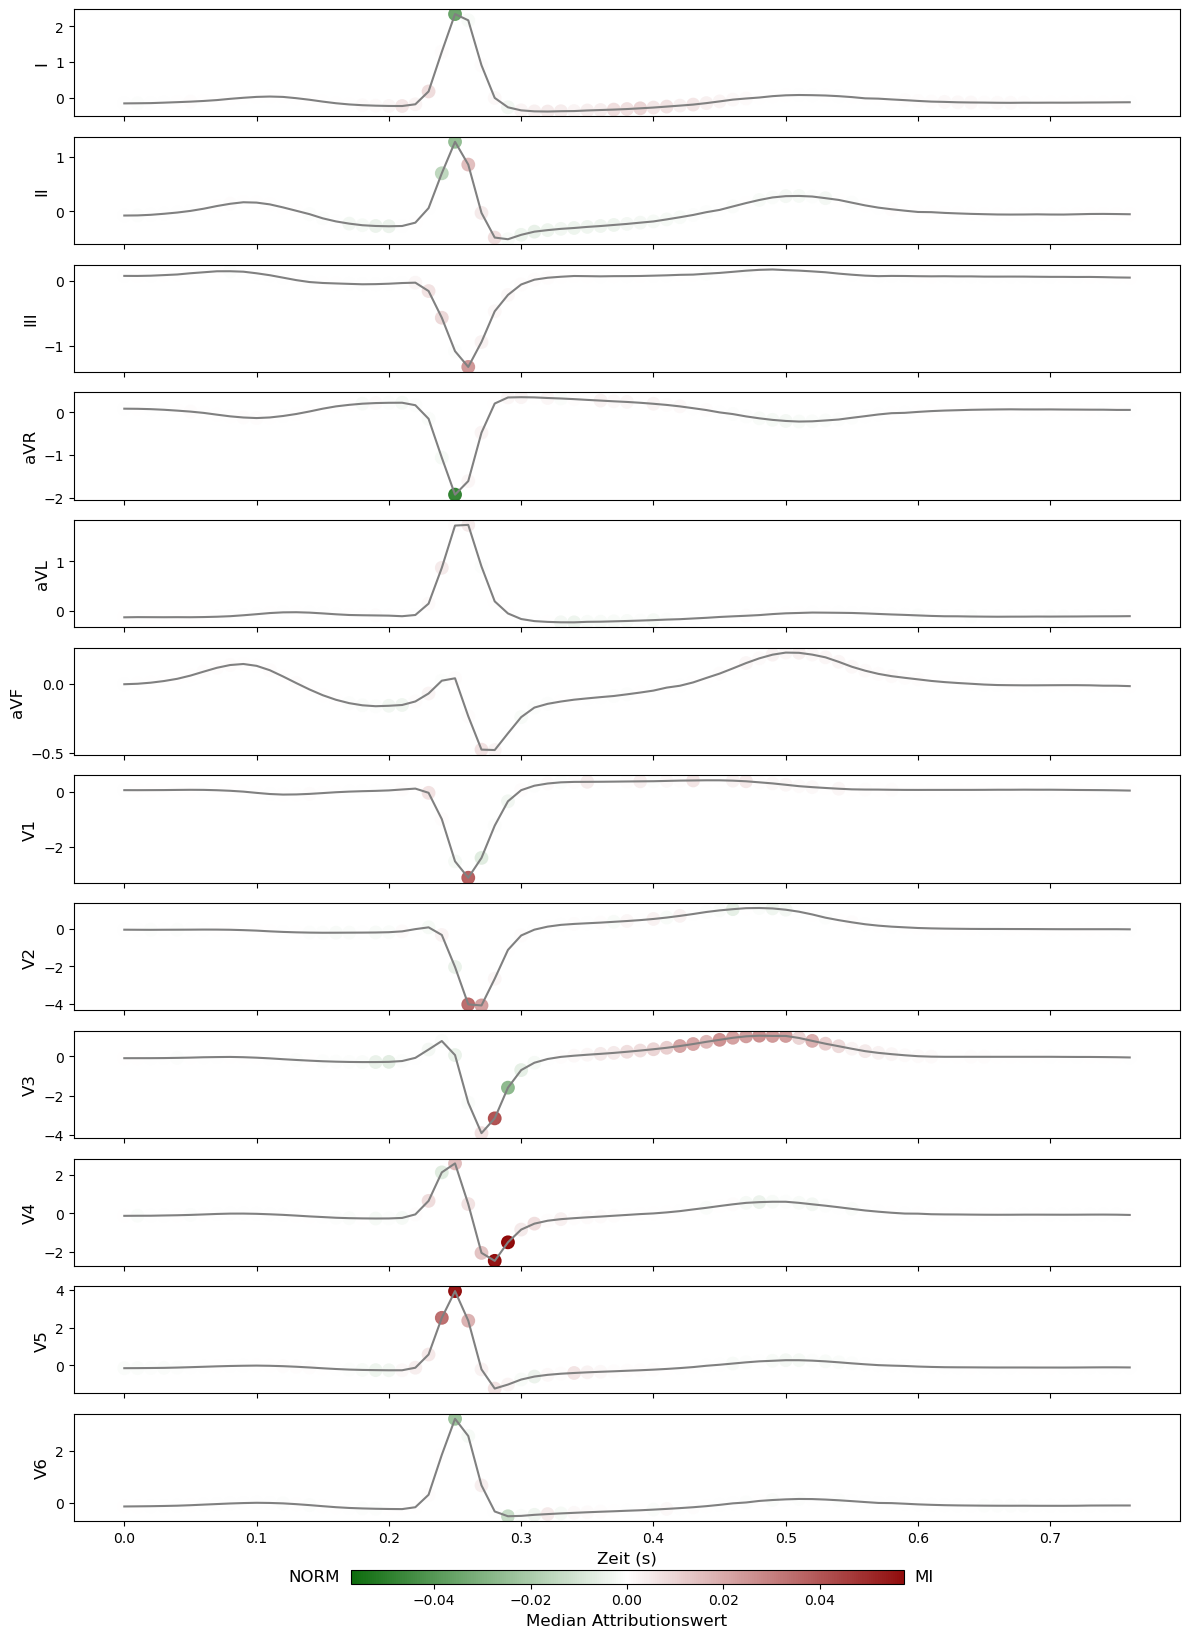

In [191]:
plot_ecg_attributions_summary(
    attributions_MI, X_test, sample_indices_MI, lead_names,
    SAMPLING_FREQUENCY, 'median', "MI", cmap_green_white_red, figsize=(12, 17))

In [203]:
# Ranking für MI-Klasse erstellen (Top 50 Attributionspunkte)
ranking_MI = create_attribution_ranking_dataframe(
    attributions_MI, 
    lead_names, 
    SAMPLING_FREQUENCY, 
    top_n=50, 
    method='median'
)

# Getrennte Rankings für MI
pos_MI, neg_MI = create_separated_attribution_ranking(attributions_MI, lead_names, SAMPLING_FREQUENCY, top_n=25)

print("\n\nTop 25 POSITIVE Attributionspunkte für MI-Klasse:")
print("=" * 70)
print(pos_MI.to_string(index=True, float_format='%.6f'))

print("\n\nTop 25 NEGATIVE Attributionspunkte für MI-Klasse:")
print("=" * 70)
print(neg_MI.to_string(index=True, float_format='%.6f'))



Top 25 POSITIVE Attributionspunkte für MI-Klasse:
   Ableitung   Zeit_s  Zeit_Sample  Attributionswert
0         V4 0.290000           29          0.057321
1         V4 0.280000           28          0.055844
2         V5 0.250000           25          0.054643
4         V3 0.280000           28          0.040253
5         V1 0.260000           26          0.036847
7         V2 0.260000           26          0.034299
8         V5 0.240000           24          0.033307
10        V3 0.480000           48          0.025645
11        V3 0.450000           45          0.025080
13       III 0.260000           26          0.023838
14        V3 0.490000           49          0.023027
15        V3 0.500000           50          0.022909
17        V3 0.470000           47          0.022664
18        V2 0.270000           27          0.022385
19        V3 0.460000           46          0.021658
20        V3 0.420000           42          0.020825
21        V3 0.430000           43          0.0

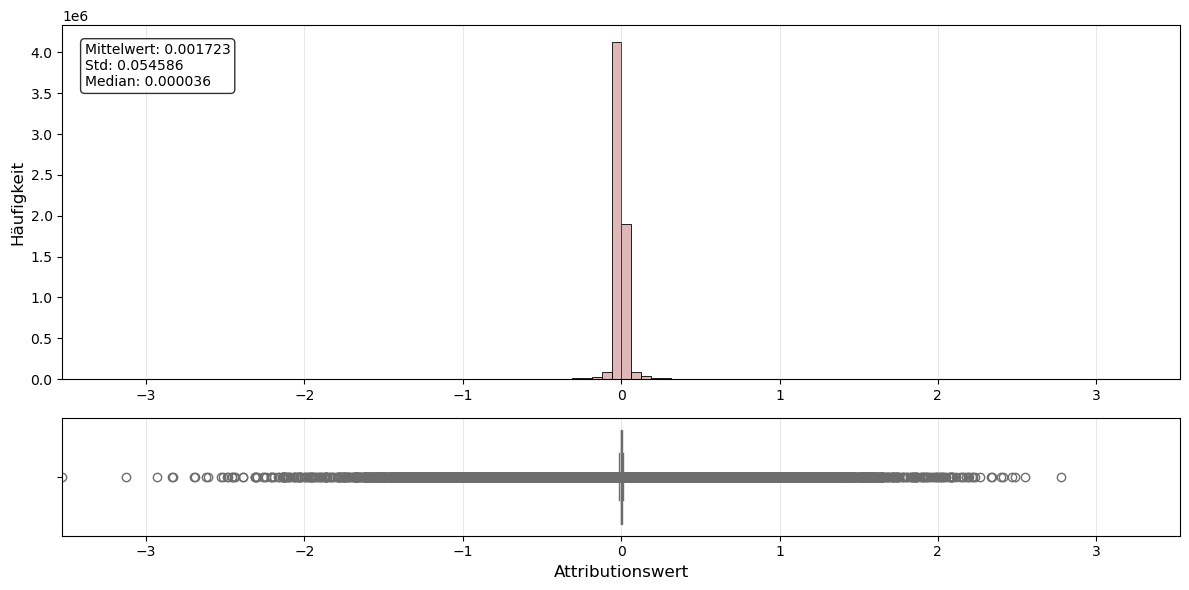

In [192]:
plot_attribution_hist_and_box(attr_flat_MI, "MI", light_red)

In [ ]:
# filter = 3
# # filter attributions
# filtered_attributions_MI = [attributions_MI[i] for i in range(len(attributions_MI)) if -filter <= convergence_deltas_MI[i] <= filter]
# filtered_attr_flat_MI = np.concatenate([attr.flatten() for attr in filtered_attributions_MI])

# # Wie viel Prozent fallen in filtered_attributions_MI rein?
# print(f"Percentage of attributions with convergence delta between -{filter} and {filter}: {len(filtered_attributions_MI) / len(attributions_MI) * 100:.2f}%")

# plot_attribution_hist_and_box(filtered_attr_flat_MI, "MI", light_red)

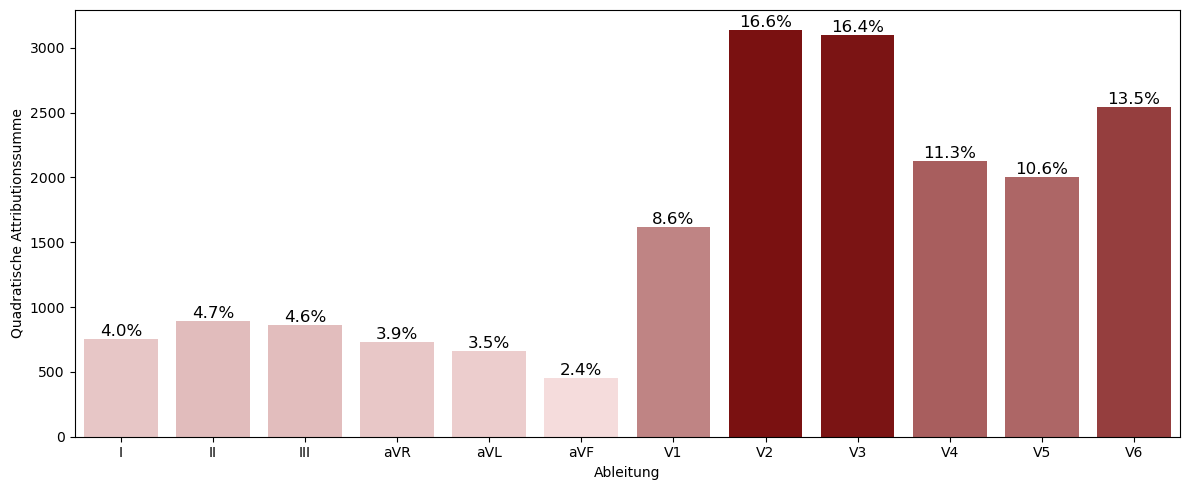

In [198]:
plot_leadwise_attribution_sum(attributions_MI, lead_names, "MI", cmap_custom_reds)
#plot_leadwise_attribution_sum(filtered_attributions_MI, lead_names, "MI - filtered", cmap_custom_reds)

# Overlapped

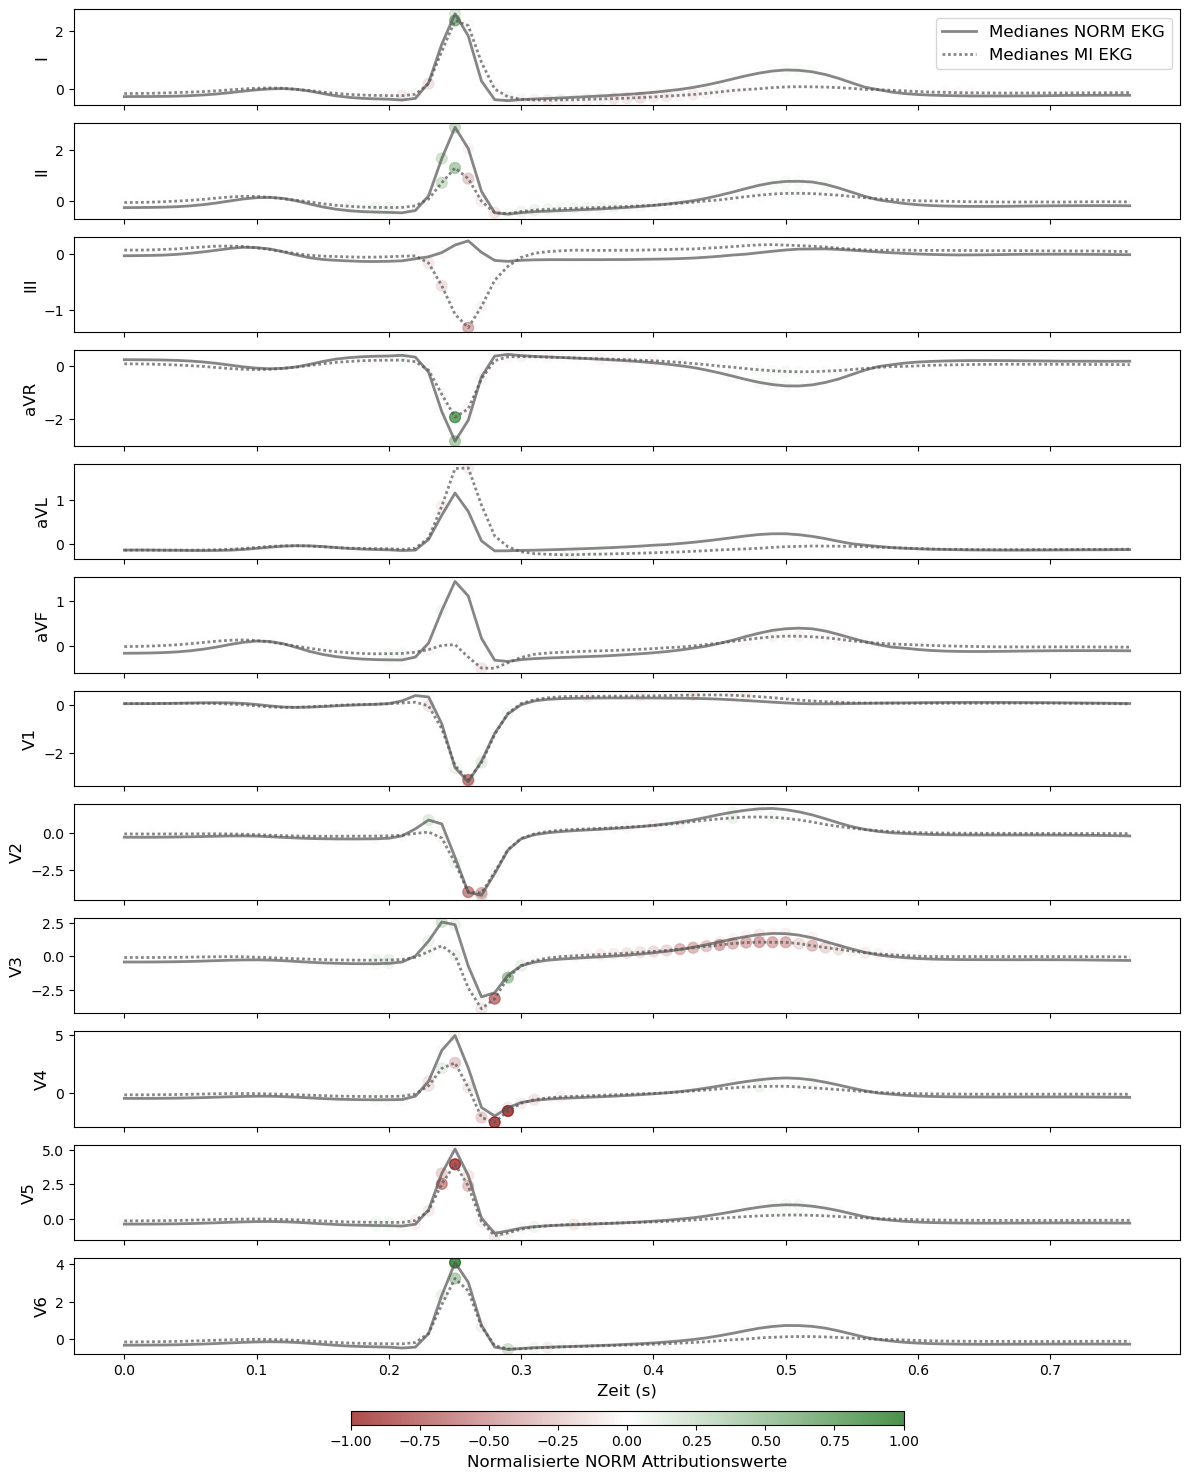

In [209]:
def plot_ecg_comparison_summary_normalized_separate_colors(attributions_1, attributions_2, X, sample_indices_1, sample_indices_2, 
                               lead_names, class_names, colors, sampling_frequency=100, method='median', 
                               color_label_1=None, color_label_2=None, figsize=(12, 17)):
    """
    Plottet mit normalisierten Attributionswerten und separaten Farbpaletten für jede Klasse
    """
    # Signale und Attributionen berechnen
    if method == 'median':
        signal_1 = mean_median_signal_per_lead_time(X, sample_indices_1, lead_names, method='median')
        signal_2 = mean_median_signal_per_lead_time(X, sample_indices_2, lead_names, method='median')
        attr_1 = median_attribution_per_lead_time(attributions_1, lead_names)
        attr_2 = median_attribution_per_lead_time(attributions_2, lead_names)
        label_prefix = 'Mediane'
    
    time_axis = np.arange(signal_1.shape[0]) / sampling_frequency
    
    # Normalisierung auf [-1, 1] basierend auf absoluten Maximalwerten
    max_abs_1 = max(abs(attr_1.min()), abs(attr_1.max()))
    max_abs_2 = max(abs(attr_2.min()), abs(attr_2.max()))
    
    attr_1_norm = attr_1 / max_abs_1 if max_abs_1 > 0 else attr_1
    attr_2_norm = attr_2 / max_abs_2 if max_abs_2 > 0 else attr_2
    
    fig, axes = plt.subplots(len(lead_names), 1, figsize=figsize, sharex=True)
    
    scatters_1 = []
    scatters_2 = []
    
    for i in range(len(lead_names)):
        # EKG-Linien
        axes[i].plot(time_axis, signal_1[:, i], color=colors[0], label=f'{label_prefix}s {class_names[0]} EKG', linewidth=2, alpha=0.7, linestyle="-")
        axes[i].plot(time_axis, signal_2[:, i], color=colors[1], label=f'{label_prefix}s {class_names[1]} EKG', linewidth=2, alpha=0.7, linestyle=(0, (1, 1)))
        
        # Normalisierte Attributionen mit separaten Farbpaletten
        scatter1 = axes[i].scatter(
            time_axis, signal_1[:, i], c=attr_1_norm[:, i],
            cmap=color_label_1, s=60, alpha=0.7, vmin=-1, vmax=1
        )
        scatter2 = axes[i].scatter(
            time_axis, signal_2[:, i], c=attr_2_norm[:, i],
            cmap=color_label_2, s=60, alpha=0.7, vmin=-1, vmax=1
        )
        
        scatters_1.append(scatter1)
        scatters_2.append(scatter2)
        axes[i].set_ylabel(lead_names[i], fontsize=12)
        
        if i == 0:
            axes[i].legend(loc='upper right', fontsize=12)

    axes[-1].set_xlabel('Zeit (s)', fontsize=12)
    plt.tight_layout()

    # Mehr Platz für Colorbar und Text reservieren
    plt.subplots_adjust(bottom=0.15)
    
    # Colorbar näher an den Plots positionieren
    cbar1 = fig.colorbar(scatters_1[0], ax=axes, orientation='horizontal', 
                         fraction=0.02, pad=0.04, aspect=40, shrink=0.5)
    cbar1.set_label(f'Normalisierte {class_names[0]} Attributionswerte', fontsize=12)

    # # Zweite Colorbar (unten)
    # cbar2 = fig.colorbar(scatters_2[0], ax=axes, orientation='horizontal', 
    #                      fraction=0.02, pad=0.04, aspect=40, shrink=0.5)
    # cbar2.set_label(f'Normalisierte {class_names[1]} Attributionswerte', fontsize=10)
    
    # Zusätzliche Info über ursprüngliche Maximalwerte - höher positionieren
    # info_text = f'Max |Attr| - {class_names[0]}: {max_abs_1:.3f}, {class_names[1]}: {max_abs_2:.3f}'
    # fig.text(0.5, 0.1, info_text, ha='center', fontsize=12, style='italic')

    plt.show()

# Verwendung mit separaten Farbpaletten:
plot_ecg_comparison_summary_normalized_separate_colors(
    attributions_NORM,
    attributions_MI,
    X_test,
    sample_indices_NORM,
    sample_indices_MI,
    lead_names,
    class_names=['NORM', 'MI'],
    colors=["#535353", "#535353"], # ["#8DA891", "#B29191"]
    sampling_frequency=SAMPLING_FREQUENCY,
    method='median',
    color_label_1=cmap_red_white_green,  # Für NORM (grün-weiß-rot)
    color_label_2=cmap_green_white_red,  # Für MI (rot-weiß-grün)
    figsize=(12, 17)
)

In [211]:
def create_attribution_ranking_dataframe_normalized(attributions, lead_names, sampling_frequency=100, top_n=100, method='median'):
    """
    Erstellt ein DataFrame mit den wichtigsten normalisierten Attributionspunkten, sortiert nach Attributionswert.
    Normalisierung erfolgt auf [-1, 1] basierend auf dem absoluten Maximum aller Attributionen.
    
    Args:
        attributions: Liste von Attributionen
        lead_names: Liste der Lead-Namen
        sampling_frequency: Sampling-Frequenz für Zeitberechnung
        top_n: Anzahl der Top-Attributionspunkte (None für alle)
        method: 'median' oder 'mean' für Aggregation über Samples
    
    Returns:
        pandas.DataFrame mit Spalten: Ableitung, Zeit_s, Zeit_Sample, Attributionswert_Original, Attributionswert_Normalisiert
    """
    
    # Attributionen berechnen basierend auf der gewählten Methode
    if method == 'median':
        attr = median_attribution_per_lead_time(attributions, lead_names)
    elif method == 'mean':
        attr = mean_attribution_per_lead_time(attributions, lead_names)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    
    # Normalisierung auf [-1, 1] basierend auf absoluten Maximalwerten
    max_abs = max(abs(attr.min()), abs(attr.max()))
    attr_norm = attr / max_abs if max_abs > 0 else attr
    
    # Listen für DataFrame erstellen
    ableitungen = []
    zeiten_s = []
    zeiten_samples = []
    attributionswerte_original = []
    attributionswerte_normalisiert = []
    
    # Durch alle Zeitpunkte und Ableitungen iterieren
    for time_idx in range(attr.shape[0]):  # Zeit-Dimension
        for lead_idx in range(attr.shape[1]):  # Lead-Dimension
            ableitungen.append(lead_names[lead_idx])
            zeiten_s.append(time_idx / sampling_frequency)
            zeiten_samples.append(time_idx)
            attributionswerte_original.append(attr[time_idx, lead_idx])
            attributionswerte_normalisiert.append(attr_norm[time_idx, lead_idx])
    
    # DataFrame erstellen
    df = pd.DataFrame({
        'Ableitung': ableitungen,
        'Zeit_s': zeiten_s,
        'Zeit_Sample': zeiten_samples,
        'Attributionswert_Original': attributionswerte_original,
        'Attributionswert_Normalisiert': attributionswerte_normalisiert
    })
    
    # Nach absolutem normalisierten Attributionswert sortieren (höchste Werte zuerst)
    df = df.reindex(df['Attributionswert_Normalisiert'].abs().sort_values(ascending=False).index)
    
    # Optional: Nur Top-N Werte zurückgeben
    if top_n is not None:
        df = df.head(top_n)
    
    # Index zurücksetzen
    df = df.reset_index(drop=True)
    
    # Zusätzliche Info über Normalisierung hinzufügen
    df.attrs['max_abs_original'] = max_abs
    
    return df

def create_separated_attribution_ranking_normalized(attributions, lead_names, sampling_frequency=100, top_n=25, method='median'):
    """
    Erstellt getrennte Rankings für positive und negative normalisierte Attributionen.
    """
    df_full = create_attribution_ranking_dataframe_normalized(attributions, lead_names, sampling_frequency, top_n=None, method=method)
    
    # Positive und negative Attributionen trennen (basierend auf normalisierten Werten)
    df_positive = df_full[df_full['Attributionswert_Normalisiert'] > 0].head(top_n)
    df_negative = df_full[df_full['Attributionswert_Normalisiert'] < 0].head(top_n)
    
    return df_positive, df_negative, df_full.attrs['max_abs_original']

# Normalisierte Rankings für NORM-Klasse
print("=" * 80)
print("NORMALISIERTE ATTRIBUTIONS-RANKINGS FÜR NORM-KLASSE")
print("=" * 80)

pos_NORM_norm, neg_NORM_norm, max_abs_NORM = create_separated_attribution_ranking_normalized(
    attributions_NORM, lead_names, SAMPLING_FREQUENCY, top_n=25, method='median'
)

print(f"\nNormalisierung basiert auf Max |Attributionswert|: {max_abs_NORM:.6f}")
print(f"Normalisierter Bereich: [-1, 1]")

print("\n\nTop 25 POSITIVE normalisierte Attributionspunkte für NORM-Klasse:")
print("=" * 80)
print(pos_NORM_norm[['Ableitung', 'Zeit_s', 'Zeit_Sample', 'Attributionswert_Original', 'Attributionswert_Normalisiert']].to_string(index=True, float_format='%.6f'))

print("\n\nTop 25 NEGATIVE normalisierte Attributionspunkte für NORM-Klasse:")
print("=" * 80)
print(neg_NORM_norm[['Ableitung', 'Zeit_s', 'Zeit_Sample', 'Attributionswert_Original', 'Attributionswert_Normalisiert']].to_string(index=True, float_format='%.6f'))

# Normalisierte Rankings für MI-Klasse
print("\n\n" + "=" * 80)
print("NORMALISIERTE ATTRIBUTIONS-RANKINGS FÜR MI-KLASSE")
print("=" * 80)

pos_MI_norm, neg_MI_norm, max_abs_MI = create_separated_attribution_ranking_normalized(
    attributions_MI, lead_names, SAMPLING_FREQUENCY, top_n=25, method='median'
)

print(f"\nNormalisierung basiert auf Max |Attributionswert|: {max_abs_MI:.6f}")
print(f"Normalisierter Bereich: [-1, 1]")

print("\n\nTop 25 POSITIVE normalisierte Attributionspunkte für MI-Klasse:")
print("=" * 80)
print(pos_MI_norm[['Ableitung', 'Zeit_s', 'Zeit_Sample', 'Attributionswert_Normalisiert']].to_string(index=True, float_format='%.6f'))

print("\n\nTop 25 NEGATIVE normalisierte Attributionspunkte für MI-Klasse:")
print("=" * 80)
print(neg_MI_norm[['Ableitung', 'Zeit_s', 'Zeit_Sample', 'Attributionswert_Normalisiert']].to_string(index=True, float_format='%.6f'))

NORMALISIERTE ATTRIBUTIONS-RANKINGS FÜR NORM-KLASSE

Normalisierung basiert auf Max |Attributionswert|: 0.544522
Normalisierter Bereich: [-1, 1]


Top 25 POSITIVE normalisierte Attributionspunkte für NORM-Klasse:
   Ableitung   Zeit_s  Zeit_Sample  Attributionswert_Original  Attributionswert_Normalisiert
0         V6 0.250000           25                   0.544522                       1.000000
1        aVR 0.250000           25                   0.231453                       0.425058
2         II 0.250000           25                   0.159944                       0.293734
3         II 0.240000           24                   0.128438                       0.235872
5         V3 0.240000           24                   0.122229                       0.224470
6         V2 0.270000           27                   0.113522                       0.208480
7          I 0.250000           25                   0.099728                       0.183149
9         V2 0.230000           23         